# Introvert vs Extrovert Analysis

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv('../data/personality_dataset.csv')

print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 2900 rows and 8 columns.


In [3]:
# Display the first 10 rows of the dataset
df.head(10)

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert
5,1.0,No,7.0,5.0,No,6.0,6.0,Extrovert
6,4.0,No,9.0,3.0,No,7.0,7.0,Extrovert
7,2.0,No,8.0,4.0,No,7.0,8.0,Extrovert
8,10.0,Yes,1.0,3.0,Yes,0.0,3.0,Introvert
9,0.0,No,8.0,6.0,No,13.0,8.0,Extrovert


In [4]:
# Data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   str    
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   str    
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   str    
dtypes: float64(5), str(3)
memory usage: 181.4 KB


Här kan vi se att Non-Null Count är lika för varje kolumn, dvs vi har inga nullvärden i datasetet men för att vara på den säkra sidan:

In [5]:
df.isnull().sum()

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64

In [6]:
# Statistical summary of the numerical columns
df.describe().round(2)

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2900.00,2900.00,2900.00,2900.00,2900.00
mean,4.51,3.96,3.00,6.27,3.56
std,3.44,2.87,2.22,4.23,2.89
min,0.00,0.00,0.00,0.00,0.00
25%,2.00,2.00,1.00,3.00,1.00
50%,4.00,3.96,3.00,5.00,3.00
75%,7.00,6.00,5.00,10.00,6.00
max,11.00,10.00,7.00,15.00,10.00


In [7]:
# Check for duplicate rows
dp_rows = df.duplicated().sum()
print(f"Number of duplicate rows to drop: {dp_rows}")

# Drop duplicate rows
df = df.drop_duplicates()

Number of duplicate rows to drop: 402


Vi vill droppa duplicerade rader då det kan ge missvisande predikationer på grund av bias.

### Target Class Balance

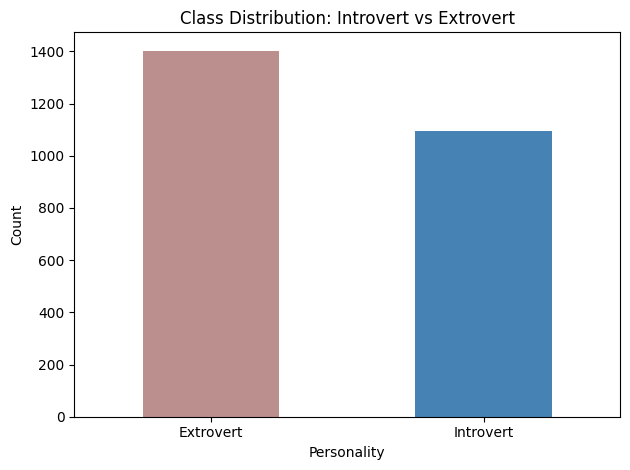

In [8]:
df['Personality'].value_counts().plot(kind='bar', color=['rosybrown', 'steelblue'])
plt.title('Class Distribution: Introvert vs Extrovert')
plt.xlabel('Personality')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Distribution

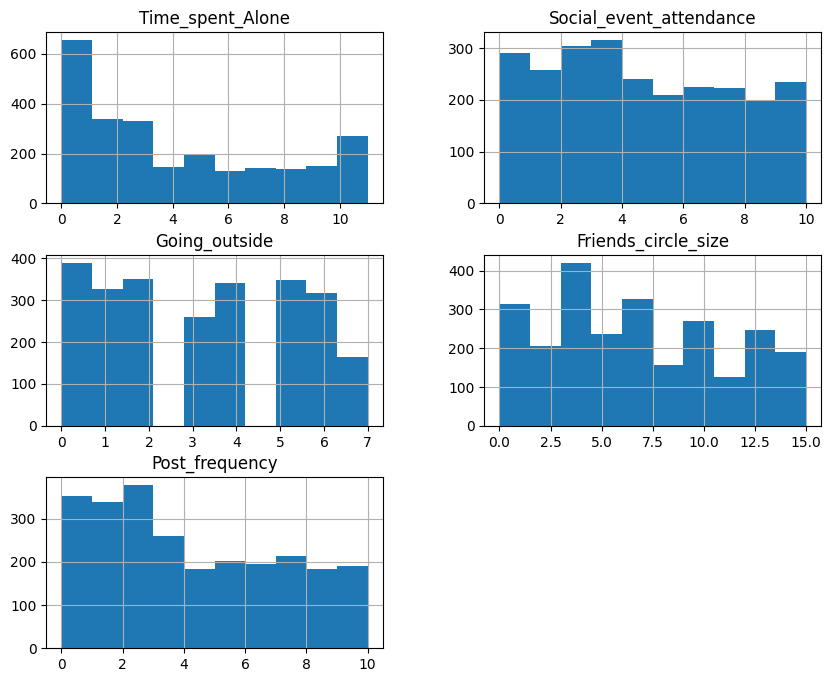

In [9]:
df.hist(figsize=(10,8))
plt.show()

### Numeric Feature vs Target

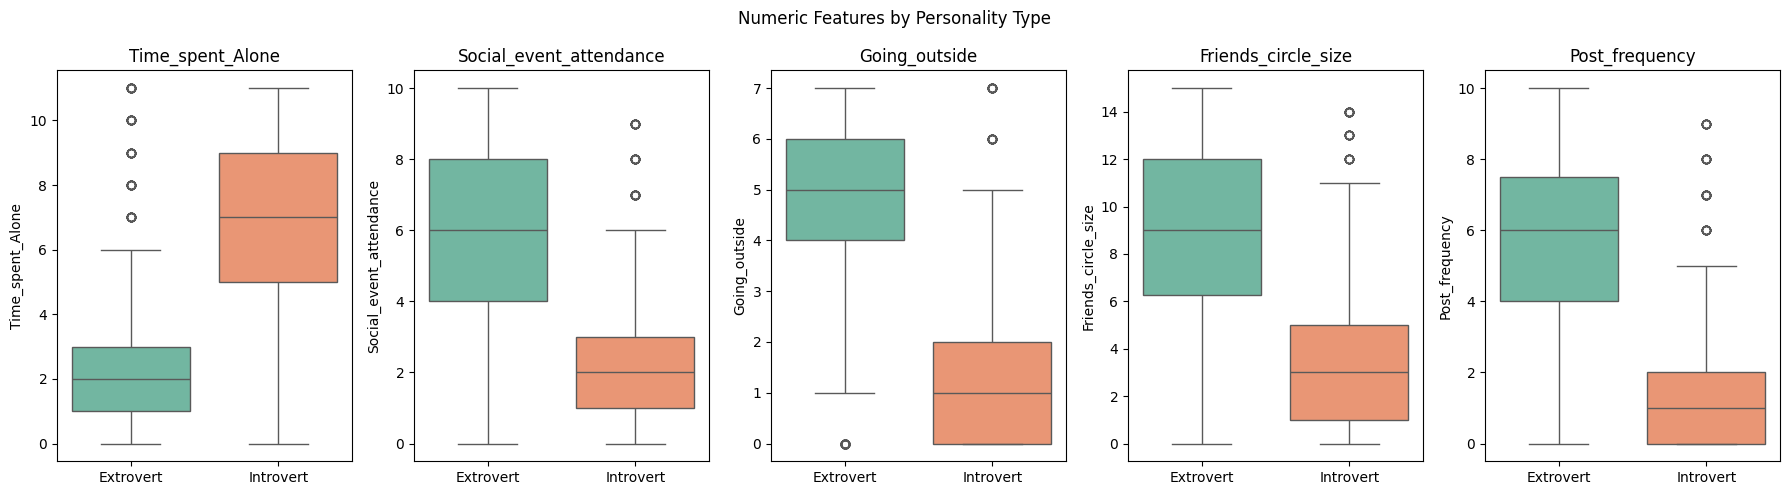

In [10]:
numerical_cols = [
    'Time_spent_Alone', 'Social_event_attendance',
    'Going_outside', 'Friends_circle_size', 'Post_frequency'
]

fig, axes = plt.subplots(1, len(numerical_cols), figsize=(18, 5))

for ax, col in zip(axes, numerical_cols):
    sns.boxplot(x='Personality', y=col, data=df, ax=ax, palette='Set2', hue='Personality')
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Numeric Features by Personality Type')
plt.tight_layout()
plt.show()

Boxplot-diagrammen visar tydliga skillnader mellan extroverta och introverta individer för samtliga numeriska variabler.

Introverta spenderar mer tid ensamma, medan extroverta i större utsträckning deltar i sociala aktiviteter, går ut oftare, har större vänkretsar och är mer aktiva på sociala medier.

Variablerna uppvisar relativt liten överlappning mellan grupperna, vilket indikerar att de är starkt prediktiva och väl lämpade för klassificering. Detta tyder på att modellen har goda förutsättningar att uppnå hög noggrannhet.

### Feature Engineering

In [11]:
# Encode target variable
if 'Personality' in df.columns:
        df['Personality'] = df['Personality'].map(
            {'Extrovert': 1, 'Introvert': 0}
        )

In [12]:
# Encoding binary categorical variables
categorical_cols = ['Stage_fear', 'Drained_after_socializing']

binary_map = {'Yes': 1, 'No': 0}
for col in categorical_cols:
    df[col] = df[col].map(binary_map)

### Correlation Heatmap

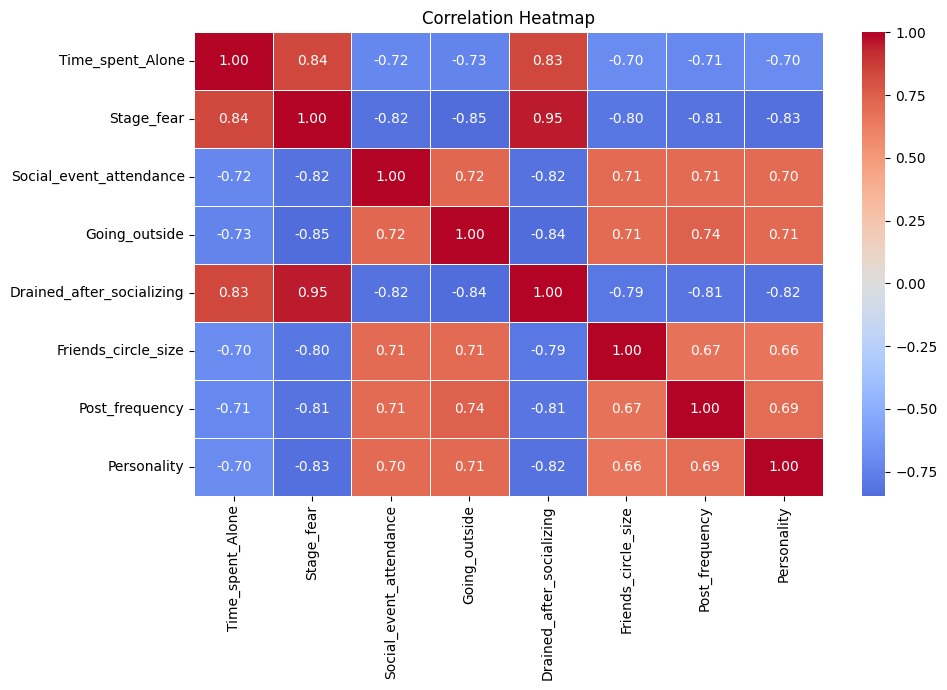

In [13]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    df.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()